In [2]:
from google import genai
from google.genai import types
from dotenv import load_dotenv
from PIL import Image
from io import BytesIO

In [3]:
load_dotenv()
client = genai.Client()

In [26]:
prompt = (
    "Create a new image by combining the elements from the provided images. Take the table and 4 chairs and place them on the pavement in the backyard from the first photo. The final image should be a backyard with a table and 4 chairs around it in a circle standing on top of the white tiled pavement."
)

In [25]:
prompt = 'Create an image by moving the perspective to view from the far right'

In [14]:
image1 = Image.open('C:/Users/Ved Office/Desktop/SAM + MiDaS/sample_images/rooms_backyards/meyer-landscape-backyard-features-to-add-value-modern-patio-home.jpg')
# image2= Image.open('/sample_images/Tables/istockphoto-531941814-612x612.jpg')
# image3 = Image.open("/sample_images/Chairs/English-Garden-Dining-Armchair_Canyon-Brown_Front-Right.jpg")

In [26]:
response1 = client.models.generate_content(
    model="gemini-2.5-flash-image",
    contents=[image1, prompt],
    config=types.GenerateContentConfig(
        image_config=types.ImageConfig(
            aspect_ratio='16:9'
        )
    )
)

In [28]:
response = client.models.generate_content(
    model="gemini-2.5-flash-image",
    contents=[image1, image2, image3, prompt],
    config=types.GenerateContentConfig(
        image_config=types.ImageConfig(
            aspect_ratio='16:9'
        )
    )
)

In [27]:
response1

GenerateContentResponse(
  automatic_function_calling_history=[],
  candidates=[
    Candidate(
      content=Content(
        parts=[
          Part(
            inline_data=Blob(
              data=<... Max depth ...>,
              mime_type=<... Max depth ...>
            )
          ),
        ],
        role='model'
      ),
      finish_reason=<FinishReason.STOP: 'STOP'>,
      index=0
    ),
  ],
  model_version='gemini-2.5-flash-image',
  response_id='IyzvaImJIbT41e8PhL7u-QI',
  sdk_http_response=HttpResponse(
    headers=<dict len=11>
  ),
  usage_metadata=GenerateContentResponseUsageMetadata(
    candidates_token_count=1290,
    candidates_tokens_details=[
      ModalityTokenCount(
        modality=<MediaModality.IMAGE: 'IMAGE'>,
        token_count=1290
      ),
    ],
    prompt_token_count=1304,
    prompt_tokens_details=[
      ModalityTokenCount(
        modality=<MediaModality.TEXT: 'TEXT'>,
        token_count=14
      ),
      ModalityTokenCount(
        modality=<Me

In [28]:
for part in response1.candidates[0].content.parts:
    if part.text is not None:
        print(part.text)
    elif part.inline_data is not None:
        image = Image.open(BytesIO(part.inline_data.data))
        image.save("generated_image_perspective_right.png")

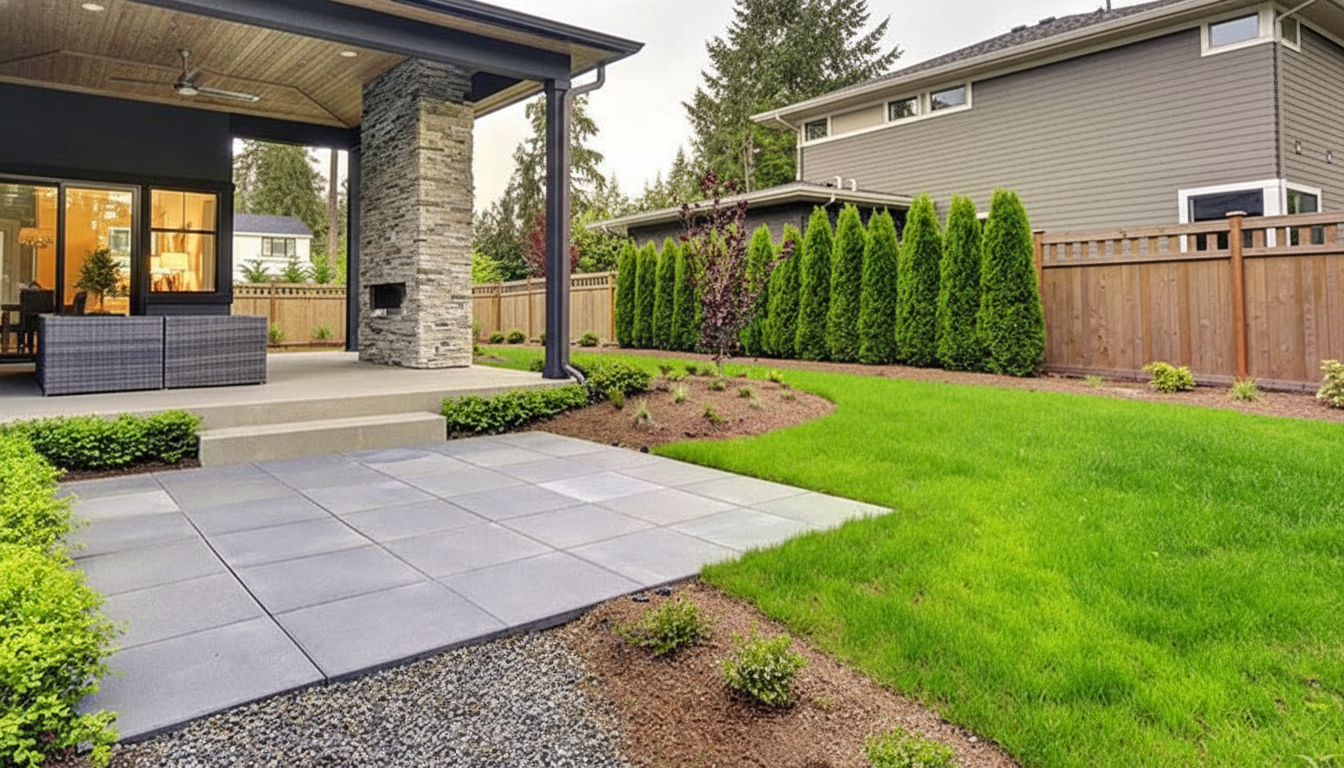

In [29]:
image

In [13]:
for part in response.candidates[0].content.parts:
    if part.text is not None:
        print(part.text)
    elif part.inline_data is not None:
        image = Image.open(BytesIO(part.inline_data.data))
        image.save("generated_image_perspective.png")

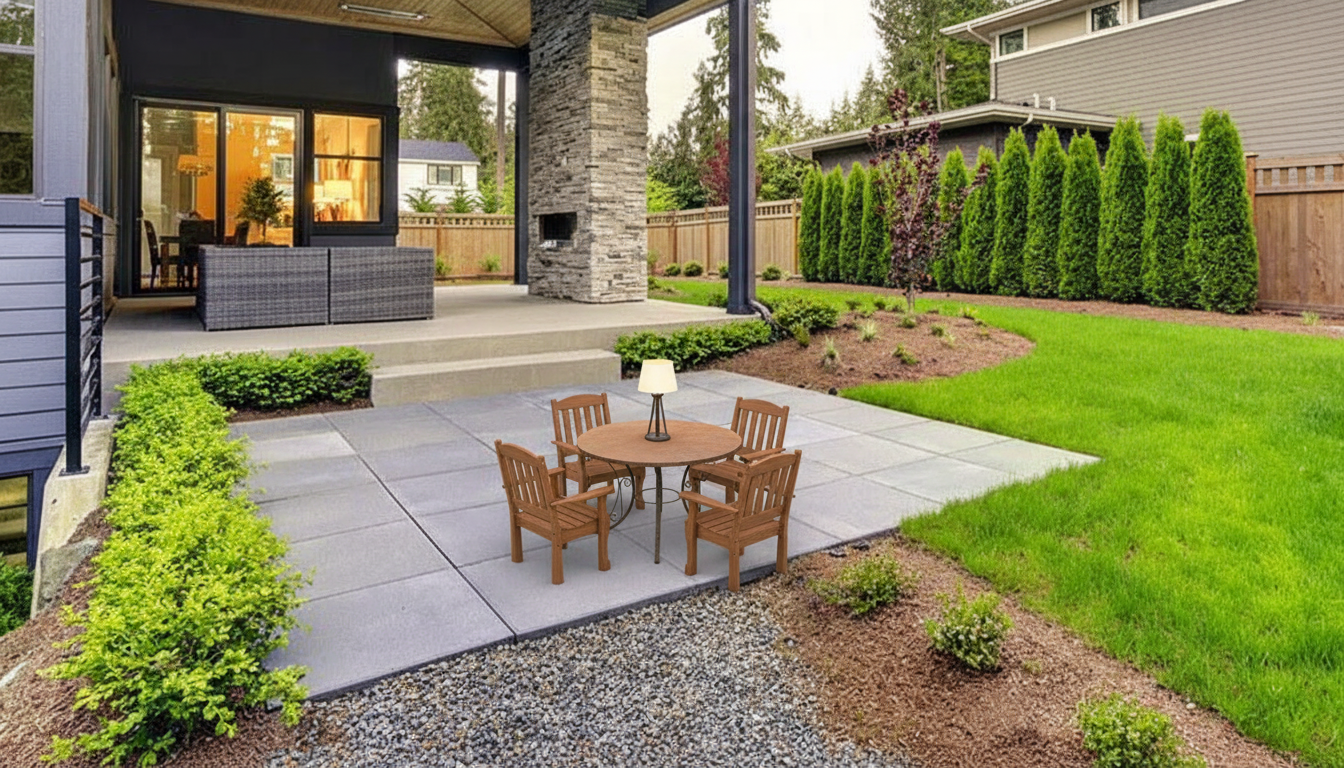

In [14]:
image

In [65]:
prompt2 = (
    'Move the table and the four chairs present in this image so that they are closer to the house in this image.'
    'Also scale the table and chairs to match the other objects in the image'
)

In [66]:
image4 = 'C:/Users/Ved Office/Desktop/SAM + MiDaS/notebooks/generated_image.png'

In [67]:
response = client.models.generate_content(
    model="gemini-2.5-flash-image",
    contents=[image1, image2, image3, prompt],
    config=types.GenerateContentConfig(
        image_config=types.ImageConfig(
            aspect_ratio='16:9'
        )
    )
)

In [68]:
for part in response.candidates[0].content.parts:
    if part.text is not None:
        print(part.text)
    elif part.inline_data is not None:
        image = Image.open(BytesIO(part.inline_data.data))
        image.save("generated_image1.png")

------Testing-----

In [1]:
import spacy
import pytextrank

C:\Users\Ved Office\Desktop\SAM + MiDaS\.venv\Lib\site-packages


In [10]:
text = "Move the table and the four chairs present in this image so that they are closer to the house in this image."
"Also scale the table and chairs to match the other objects in the image"

# load a spaCy model, depending on language, scale, etc.
nlp = spacy.load("en_core_web_sm")

# add PyTextRank to the spaCy pipeline
nlp.add_pipe("textrank")
doc = nlp(text)

# examine the top-ranked phrases in the document
for phrase in doc._.phrases:
    print(phrase.text)

this image
the table
the house
the four chairs
four
they
